# Steerable Convolution on Tetris (Step-by-Step)

**6.7970/8.750 Symmetry and its Application to Machine Learning**

This notebook builds a **steerable $D_4$-equivariant CNN** from scratch, enumerating each CG coupling path explicitly. For the streamlined one-call version, see the [companion notebook](steerable_tetris_dense.ipynb).

The key ideas:

1. Features at each pixel are vectors of **irrep components** — starting as scalars ($A_1$) and getting **promoted** to richer irrep content through tensor products.
2. Convolution filters are **linear combinations of fixed basis elements** (CG coefficients $\times$ spatial basis functions), with only **scalar weights** learned.
3. For images on a fixed grid, we can **precompute** the CG $\times$ spatial basis once — the learned part is just one scalar per coupling path per channel pair. (This precomputation is NOT possible for graph neural networks, where neighbor positions vary per example.)
4. The **irrep content** of hidden features (how many copies of each irrep) is a hyperparameter — analogous to choosing the number of channels in a standard CNN.

In [ ]:
%%capture
!pip install pymatgen
!pip install https://symm4ml.mit.edu/_static/symm4ml_s26/symm4ml/symm4ml_latest.zip

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from symm4ml import groups, rep, linalg
from symm4ml.group_conv import (
    apply_group_element_2D,
    image2D_permutation_representation,
)
from symm4ml.steerable import (
    spatial_basis_functions,
    steerable_kernel_basis,
    norm_activation,
    content_norm_slices,
    SteerableConv2d,
)

torch.manual_seed(42)
np.random.seed(42)

---
## 1. Setup: $D_4$ Group and Irreps

We build the dihedral group $D_4$ (symmetries of a square: 4 rotations + 4 reflections = 8 elements) and compute its **canonical irreducible representations**.

$D_4$ has 5 irreps:
- **$A_1$** (dim 1): trivial — all elements act as $+1$
- **$A_2$** (dim 1): pseudoscalar — rotations $\to +1$, reflections $\to -1$
- **$B_1$** (dim 1): sign flips under 90° rotation
- **$B_2$** (dim 1): sign flips under 90° rotation (different from $B_1$)
- **$E$** (dim 2): the standard 2D rotation/reflection matrices

We align the 2D irrep $E$ with the **geometric vector representation** — the actual 2×2 rotation/reflection matrices. This pins the basis to physical $(x, y)$ directions.

In [2]:
# Generate D4 from 90° rotation and mirror
rot90 = np.array([[0., -1.], [1., 0.]])
sigma_v = np.array([[-1., 0.], [0., 1.]])
D4 = np.array(groups.generate_group(np.stack([sigma_v, rot90]))[::-1])  # E first
D4_table = groups.make_multiplication_table(D4)
D4_torch = torch.tensor(D4, dtype=torch.float32)

print(f"D4: {len(D4)} elements")

# --- Construct the irreps manually ---

# infer_irreps finds them, but in an arbitrary complex basis
np.random.seed(0)
D4_irreps_raw = rep.infer_irreps(D4_table)

# Cast to real (all D4 irreps have real representations)
D4_irreps = [ir.real for ir in D4_irreps_raw]

# Replace E (the 2D irrep) with the geometric vector representation —
# the actual 2×2 rotation/reflection matrices. This pins the basis to (x, y).
E_idx = next(i for i, ir in enumerate(D4_irreps) if ir.shape[1] == 2)
D4_irreps[E_idx] = D4.copy()

# Label the 1D irreps using the character table
dets = np.array([np.linalg.det(D4[g]) for g in range(len(D4))])
is_rot = dets > 0  # rotations have det=+1, reflections have det=-1

irrep_labels = [None] * 5
for i, ir in enumerate(D4_irreps):
    if ir.shape[1] == 2:
        irrep_labels[i] = 'E'
    elif ir.shape[1] == 1:
        vals = ir[:, 0, 0]
        if np.allclose(vals, 1):
            irrep_labels[i] = 'A1'
        elif np.allclose(vals[is_rot], 1) and np.allclose(vals[~is_rot], -1):
            irrep_labels[i] = 'A2'
        else:
            # B1 vs B2: check sign on σ_v
            if vals[1] > 0:
                irrep_labels[i] = 'B1'
            else:
                irrep_labels[i] = 'B2'

print(f"\nIrreps (canonical):")
for label, ir in zip(irrep_labels, D4_irreps):
    print(f"  {label}: dim {ir.shape[1]}")
print(f"\nTotal: {sum(ir.shape[1]**2 for ir in D4_irreps)} = |G| = {len(D4)} ✓")

D4: 8 elements

Irreps (canonical):
  A1: dim 1
  B2: dim 1
  B1: dim 1
  A2: dim 1
  E: dim 2

Total: 8 = |G| = 8 ✓


---
## 2. Spatial Basis Functions for 3×3 Kernels

A 3×3 convolution kernel has 9 pixels. When $D_4$ acts on the pixel grid (rotating/reflecting coordinates), the 9 pixels permute among themselves. This **permutation representation** decomposes into irreps, giving us **spatial basis functions** — fixed pixel patterns that transform cleanly under the group.

For a 3×3 kernel under $D_4$: $\Gamma^{\text{pix}} = 3A_1 \oplus B_1 \oplus B_2 \oplus 2E$

Note: **no $A_2$** appears in a 3×3 kernel — you'd need a larger kernel to get $A_2$ spatial patterns.

In [3]:
# Permutation representation of D4 on 3×3 pixel grid
perm_rep_3x3 = image2D_permutation_representation(D4_torch, [3, 3])

# Decompose into irrep-labeled spatial basis functions
sp_basis = spatial_basis_functions(perm_rep_3x3.numpy(), D4_irreps)

print("Spatial basis functions for 3×3 kernel under D4:")
total = 0
for label, sb in zip(irrep_labels, sp_basis):
    n_copies, dim, n_pix = sb.shape
    n_funcs = n_copies * dim
    total += n_funcs
    if n_copies > 0:
        print(f"  {label}: {n_copies} {'copy' if n_copies == 1 else 'copies'} × dim {dim} = {n_funcs} functions")
    else:
        print(f"  {label}: not present in 3×3 kernel")
print(f"  Total: {total} = 9 pixels ✓")

Spatial basis functions for 3×3 kernel under D4:
  A1: 3 copies × dim 1 = 3 functions
  B2: 1 copy × dim 1 = 1 functions
  B1: 1 copy × dim 1 = 1 functions
  A2: not present in 3×3 kernel
  E: 2 copies × dim 2 = 4 functions
  Total: 9 = 9 pixels ✓


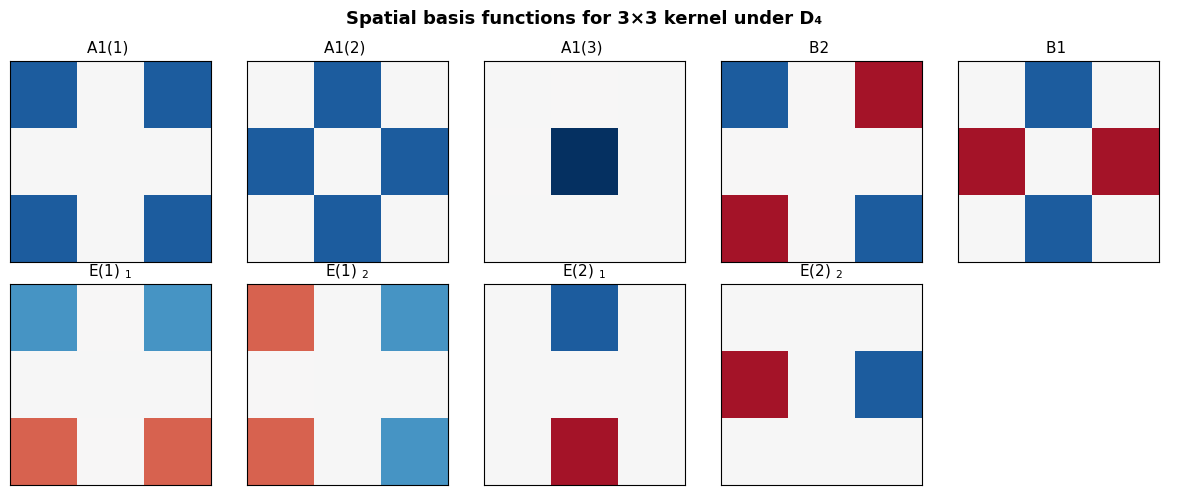

In [4]:
# Visualize the 9 spatial basis functions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
plot_idx = 0
for label, sb in zip(irrep_labels, sp_basis):
    for copy in range(sb.shape[0]):
        for row in range(sb.shape[1]):
            if plot_idx >= 10:
                break
            ax = axes[plot_idx // 5, plot_idx % 5]
            grid = sb[copy, row].reshape(3, 3)
            ax.imshow(grid, cmap='RdBu', vmin=-0.6, vmax=0.6, interpolation='nearest')
            suffix = f'({copy+1})' if sb.shape[0] > 1 else ''
            row_lbl = f'$_{ {row+1} }$' if sb.shape[1] > 1 else ''
            ax.set_title(f'{label}{suffix} {row_lbl}', fontsize=11)
            ax.set_xticks([]); ax.set_yticks([])
            plot_idx += 1

for j in range(plot_idx, 10):
    axes[j // 5, j % 5].axis('off')
fig.suptitle('Spatial basis functions for 3×3 kernel under D₄', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. CG Paths: How Irreps Couple Through Convolution

In a steerable convolution, the filter couples **input features** (irrep components) with **spatial patterns** (also irrep-labeled) to produce **output features**. The allowed couplings are determined by **Clebsch–Gordan (CG) coefficients**: given input irrep $\alpha$, spatial irrep $\beta$, the CG coefficients tell us which output irreps $\gamma$ can be produced, and how.

Each valid coupling path $(\alpha \otimes \beta \to \gamma)$ gets **one learnable scalar weight**. The CG coefficient itself is a fixed tensor — only the scalar multiplier is learned. This is what makes steerable convolution parameter-efficient: the group theory constrains the filter to a low-dimensional subspace.

### Feature promotion

Input images are **scalar fields** — they transform as the trivial irrep $A_1$. After the first convolution (lifting), the features get **promoted** to richer irrep content through tensor products with the spatial basis:

- $A_1 \otimes A_1^{\text{spatial}} \to A_1$ (3 paths, since 3 copies of $A_1$ spatial basis)
- $A_1 \otimes B_1^{\text{spatial}} \to B_1$ (1 path)
- $A_1 \otimes B_2^{\text{spatial}} \to B_2$ (1 path)
- $A_1 \otimes E^{\text{spatial}} \to E$ (2 paths, since 2 copies of $E$ spatial basis)

So scalar input → features with $A_1$, $B_1$, $B_2$, and $E$ components. Each subsequent layer can couple these richer features with all the spatial patterns, producing even more diverse couplings.

In [5]:
# Show CG paths for the lifting layer (scalar → hidden)
print("CG selection rules for A1 input × spatial basis → output:")
print("(each allowed path = one learnable scalar)\n")

A1_idx = irrep_labels.index('A1')

for sp_idx, (sp_label, sb) in enumerate(zip(irrep_labels, sp_basis)):
    if sb.shape[0] == 0:
        continue
    n_sp_copies = sb.shape[0]
    for out_idx, out_label in enumerate(irrep_labels):
        # reduce_tensor_product returns [n_paths, d1, d2, d_out]
        cg = rep.reduce_tensor_product(D4_irreps[A1_idx], D4_irreps[sp_idx], D4_irreps[out_idx])
        n_cg_paths = cg.shape[0]
        if n_cg_paths > 0:
            total_paths = n_cg_paths * n_sp_copies
            print(f"  A1 ⊗ {sp_label} → {out_label}: {n_cg_paths} CG path(s) × {n_sp_copies} spatial {'copy' if n_sp_copies == 1 else 'copies'} = {total_paths} basis element(s)")

CG selection rules for A1 input × spatial basis → output:
(each allowed path = one learnable scalar)

  A1 ⊗ A1 → A1: 1 CG path(s) × 3 spatial copies = 3 basis element(s)
  A1 ⊗ B2 → B2: 1 CG path(s) × 1 spatial copy = 1 basis element(s)
  A1 ⊗ B1 → B1: 1 CG path(s) × 1 spatial copy = 1 basis element(s)
  A1 ⊗ E → E: 1 CG path(s) × 2 spatial copies = 2 basis element(s)


---
## 4. Irrep Content: The Hyperparameter

The **irrep content** of hidden features — how many copies of each irrep to carry — is a design choice, analogous to choosing channel widths in a standard CNN.

Some natural choices for $D_4$:

| Content | Dimension | Notes |
|---|---|---|
| $A_1 + A_2 + B_1 + B_2 + E$ | 6 | One copy of each irrep |
| $A_1 + A_2 + B_1 + B_2 + 2E$ | 8 | Same as the **regular representation** |
| $2(A_1 + A_2 + B_1 + B_2 + E)$ | 12 | Two copies of everything |

More copies = more learnable paths = more expressive, but also more parameters. We'll start with one copy of each (dim 6).

In [6]:
# Irrep indices (in the order infer_irreps returned them)
# Use irrep_labels to find the index of each irrep by name
A1 = irrep_labels.index('A1')
A2 = irrep_labels.index('A2')
B1 = irrep_labels.index('B1')
B2 = irrep_labels.index('B2')
E  = irrep_labels.index('E')

# Input: scalar image → trivial rep only
scalar_content = [(A1, 1)]   # 1×A1 → dim 1

# Hidden: one copy of each irrep, E appears twice (= regular rep content)
# This is THE HYPERPARAMETER — try different choices in Section 10!
hidden_content = [(A1, 1), (A2, 1), (B1, 1), (B2, 1), (E, 2)]
# = A1 + A2 + B1 + B2 + 2E = 1+1+1+1+4 = 8 dim (same as regular rep!)

# Norm activation needs to know where each irrep block sits
hidden_slices = content_norm_slices(hidden_content, D4_irreps)

print(f"Hidden feature dimension: {sum(d for _,_,d in hidden_slices)}")
print(f"Irrep blocks (start, end, dim):")
block_names = ['A1', 'A2', 'B1', 'B2', 'E', 'E']
for (s, e, d), name in zip(hidden_slices, block_names):
    print(f"  {name}: [{s}:{e}]  (dim {d})")

Hidden feature dimension: 8
Irrep blocks (start, end, dim):
  A1: [0:1]  (dim 1)
  A2: [1:2]  (dim 1)
  B1: [2:3]  (dim 1)
  B2: [3:4]  (dim 1)
  E: [4:6]  (dim 2)
  E: [6:8]  (dim 2)


---
## 5. Precompute Basis Elements

For each layer, we precompute **all valid CG × spatial basis elements** by iterating over every (input irrep, spatial irrep, output irrep) triple. Each valid triple gives a fixed tensor of shape `[d_out, d_in, kh×kw]` — a basis kernel that maps input irrep features to output irrep features through a specific spatial pattern.

This piecewise enumeration lets us see each coupling path explicitly. The same basis elements can also be computed in **one call** via `reduce_tensor_product(rho_in, rho_spatial, rho_out)` — see the [companion notebook](steerable_tetris_dense.ipynb).

**Images vs. graphs:** because pixel positions in the kernel are fixed, we can contract CG coefficients with spatial basis functions once at initialization. The learned filter is then:

$$K(\mathbf{y}) = \sum_w \alpha_w \cdot Q_w(\mathbf{y})$$

where $Q_w$ are fixed basis elements and $\alpha_w$ are the learnable scalars. In a **graph neural network**, neighbor positions vary per node, so this precomputation is not possible.

In [7]:
# Precompute basis for lifting layer: scalar → hidden
lift_basis_elems, lift_info, n_lift, _, _ = steerable_kernel_basis(
    D4_irreps, sp_basis, input_content=scalar_content, output_content=hidden_content)

# Precompute basis for hidden → hidden layer
conv_basis_elems, conv_info, n_conv, _, _ = steerable_kernel_basis(
    D4_irreps, sp_basis, input_content=hidden_content, output_content=hidden_content)

print(f"Lifting layer: {n_lift} basis elements (CG paths)")
print(f"  → {n_lift} learnable scalars per (c_out, c_in) channel pair")
print(f"\nHidden→hidden layer: {n_conv} basis elements")
print(f"  → {n_conv} learnable scalars per (c_out, c_in) channel pair")

# Show what each basis element couples
print(f"\nLifting layer coupling paths:")
for i, info in enumerate(lift_info):
    in_name = irrep_labels[info['in_irrep']]
    out_name = irrep_labels[info['out_irrep']]
    sp_name = irrep_labels[info['spatial_irrep']]
    print(f"  path {i}: {in_name} ⊗ {sp_name}(copy {info['spatial_copy']}) → {out_name}")

Lifting layer: 9 basis elements (CG paths)
  → 9 learnable scalars per (c_out, c_in) channel pair

Hidden→hidden layer: 72 basis elements
  → 72 learnable scalars per (c_out, c_in) channel pair

Lifting layer coupling paths:
  path 0: A1 ⊗ A1(copy 0) → A1
  path 1: A1 ⊗ A1(copy 1) → A1
  path 2: A1 ⊗ A1(copy 2) → A1
  path 3: A1 ⊗ B1(copy 0) → B1
  path 4: A1 ⊗ B2(copy 0) → B2
  path 5: A1 ⊗ E(copy 0) → E
  path 6: A1 ⊗ E(copy 1) → E
  path 7: A1 ⊗ E(copy 0) → E
  path 8: A1 ⊗ E(copy 1) → E


---
## 6. Build the Steerable CNN

The model has two `SteerableConv2d` layers. The first takes scalar ($A_1$) input and produces hidden features with the full irrep content — this is where features get **promoted** from scalar to richer irrep structure. The second maps hidden→hidden.

Each layer stores the precomputed CG × spatial basis as a buffer and learns scalar weights. The weight tensor has shape `[c_out, c_in, n_basis]` — the convolution is **fully connected** over channels: each output channel mixes all input channels. This works because every channel carries the same irrep content, so the same basis elements apply to every `(c_out, c_in)` pair.

### Norm-based activations

In the regular-rep approach, ReLU works because the group acts by **permuting** components (0s and 1s — no floating point error from the group action). In the irrep basis, the group acts by **rotations/reflections** that mix components — pointwise ReLU breaks equivariance.

The fix: use the **norm** (which is invariant under the group) to gate each irrep block.

- **Scalars ($A_1$)**: the group acts as $+1$, so pointwise `ReLU(x + b)` with a learned bias is equivariant.
- **Non-scalars** ($A_2$, $B_1$, $B_2$, $E$): apply $\sigma(\|x\| + b) \cdot x / \|x\|$. The norm is invariant, so the learned bias $b$ shifts the activation threshold without breaking equivariance. The key: the bias is on the **norm** (an invariant scalar), not on the feature vector itself — adding a bias directly to $x$ would break equivariance.

In [8]:
class SteerableTetrisCNN(nn.Module):
    def __init__(self, c=8, num_classes=5):
        super().__init__()
        self.conv1 = SteerableConv2d(1, c, lift_basis_elems, kernel_size=(3, 3))
        self.conv2 = SteerableConv2d(c, c, conv_basis_elems, kernel_size=(3, 3))
        self.fc = nn.Linear(c, num_classes)
        self.hidden_slices = hidden_slices
        # One bias per irrep block: on scalar values for A1, on norms for others
        n_blocks = len(hidden_slices)
        self.act_bias1 = nn.Parameter(torch.zeros(n_blocks))
        self.act_bias2 = nn.Parameter(torch.zeros(n_blocks))

    def forward(self, x):
        # x: [batch, 1, H, W] — scalar image
        x = x.unsqueeze(2)                              # [batch, 1, 1, H, W] — add trivial irrep dim
        x = self.conv1(x)                               # [batch, c, 8, H, W] — promoted to hidden irreps
        x = norm_activation(x, self.hidden_slices, self.act_bias1)
        x = self.conv2(x)                               # [batch, c, 8, H, W]
        x = norm_activation(x, self.hidden_slices, self.act_bias2)
        x = x.mean(dim=(-2, -1))                        # spatial pool → [batch, c, 8]
        x = x[:, :, 0]                                  # A1 projection → [batch, c]
        return self.fc(x)


model = SteerableTetrisCNN()
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")
print(f"  Conv1 weights: {model.conv1.weight.shape} = {model.conv1.weight.numel()}")
print(f"  Conv2 weights: {model.conv2.weight.shape} = {model.conv2.weight.numel()}")
print(f"  Act biases:    {model.act_bias1.numel() + model.act_bias2.numel()} (on values for A1, on norms for others)")
print(f"  FC:            {sum(p.numel() for p in model.fc.parameters())}")

Model parameters: 4,737
  Conv1 weights: torch.Size([8, 1, 9]) = 72
  Conv2 weights: torch.Size([8, 8, 72]) = 4608
  Act biases:    12 (on values for A1, on norms for others)
  FC:            45


---
## 7. Tetris Pieces and Data

In [9]:
PIECES = {
    'I': np.array([[-2, 0], [-1, 0], [0, 0], [1, 0]]),
    'O': np.array([[0, 0], [0, 1], [1, 0], [1, 1]]),
    'T': np.array([[0, -1], [0, 0], [0, 1], [1, 0]]),
    'S': np.array([[0, 0], [0, 1], [1, -1], [1, 0]]),
    'Z': np.array([[0, -1], [0, 0], [1, 0], [1, 1]]),
    'L': np.array([[-1, 0], [0, 0], [1, 0], [1, 1]]),
    'J': np.array([[-1, 0], [0, 0], [1, 0], [1, -1]]),
}
PIECE_NAMES = list(PIECES.keys())
GRID_SIZE = 9
CENTER = GRID_SIZE // 2
MARGIN = 2  # keep pieces this far from grid boundary (avoids conv padding artifacts)

# D4: 5 classes (L↔J and S↔Z are related by reflection)
D4_CLASSES = {'I': 0, 'O': 1, 'T': 2, 'S': 3, 'Z': 3, 'L': 4, 'J': 4}
D4_CLASS_NAMES = ['I', 'O', 'T', 'S/Z', 'L/J']


def place_piece(coords, grid_size=9, translation=None, margin=0):
    min_r, max_r = coords[:, 0].min(), coords[:, 0].max()
    min_c, max_c = coords[:, 1].min(), coords[:, 1].max()
    if translation is None:
        tr = np.random.randint(-min_r + margin, grid_size - max_r - margin)
        tc = np.random.randint(-min_c + margin, grid_size - max_c - margin)
    else:
        tr, tc = translation
    img = np.zeros((grid_size, grid_size))
    for r, c in coords:
        img[r + tr, c + tc] = 1.0
    return img


def make_training_set():
    """One centered image per class."""
    seen = set()
    pieces = []
    for name in PIECE_NAMES:
        if D4_CLASSES[name] not in seen:
            seen.add(D4_CLASSES[name])
            pieces.append(name)
    imgs = [place_piece(PIECES[n], GRID_SIZE, (CENTER, CENTER)) for n in pieces]
    labels = [D4_CLASSES[n] for n in pieces]
    return (torch.tensor(np.array(imgs), dtype=torch.float32).unsqueeze(1),
            torch.tensor(labels, dtype=torch.long), pieces)


def make_test_set(n_per_piece=100):
    """Random D4 orientations and positions (with margin from boundary)."""
    imgs, labels = [], []
    for name, coords in PIECES.items():
        for _ in range(n_per_piece):
            g_idx = np.random.randint(len(D4))
            rotated = apply_group_element_2D(coords, D4[g_idx])
            imgs.append(place_piece(rotated, GRID_SIZE, margin=MARGIN))
            labels.append(D4_CLASSES[name])
    return (torch.tensor(np.array(imgs), dtype=torch.float32).unsqueeze(1),
            torch.tensor(labels, dtype=torch.long))


train_imgs, train_labels, train_pieces = make_training_set()
test_imgs, test_labels = make_test_set()
print(f"Training: {len(train_labels)} centered images ({train_pieces})")
print(f"Test: {len(test_labels)} images (random D4 transforms + positions, margin={MARGIN})")

Training: 5 centered images (['I', 'O', 'T', 'S', 'L'])
Test: 700 images (random D4 transforms + positions, margin=2)


---
## 8. Train

In [10]:
def train_model(model, train_imgs, train_labels, test_imgs, test_labels,
                epochs=200, lr=1e-2):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        logits = model(train_imgs)
        loss = criterion(logits, train_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_acc = (model(train_imgs).argmax(1) == train_labels).float().mean().item()
            test_acc = (model(test_imgs).argmax(1) == test_labels).float().mean().item()
        history['loss'].append(loss.item())
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        if (epoch + 1) % 25 == 0:
            print(f"Epoch {epoch+1:3d}: loss={loss.item():.4f}  "
                  f"train_acc={train_acc:.3f}  test_acc={test_acc:.3f}")
    return history


torch.manual_seed(0)
model = SteerableTetrisCNN()
history = train_model(model, train_imgs, train_labels, test_imgs, test_labels)

Epoch  25: loss=1.5010  train_acc=0.800  test_acc=0.857
Epoch  50: loss=1.0911  train_acc=1.000  test_acc=1.000
Epoch  75: loss=0.6720  train_acc=1.000  test_acc=1.000
Epoch 100: loss=0.3403  train_acc=1.000  test_acc=1.000
Epoch 125: loss=0.1525  train_acc=1.000  test_acc=1.000
Epoch 150: loss=0.0656  train_acc=1.000  test_acc=1.000
Epoch 175: loss=0.0342  train_acc=1.000  test_acc=1.000
Epoch 200: loss=0.0212  train_acc=1.000  test_acc=1.000


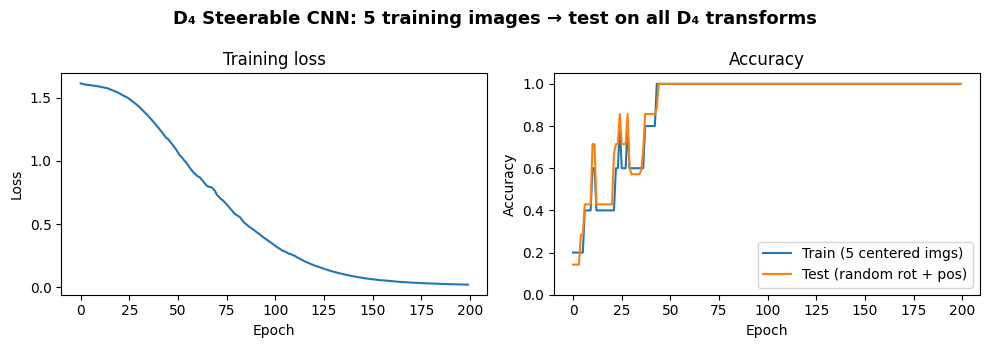

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(history['loss']); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training loss')
ax2.plot(history['train_acc'], label=f'Train ({len(train_labels)} centered imgs)')
ax2.plot(history['test_acc'], label='Test (random rot + pos)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.set_ylim(0, 1.05)
ax2.set_title('Accuracy')
fig.suptitle('D₄ Steerable CNN: 5 training images → test on all D₄ transforms',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Verify Equivariance

The model should give **identical logits** for all $D_4$ orientations of the same piece — equivariance is built in, not learned.

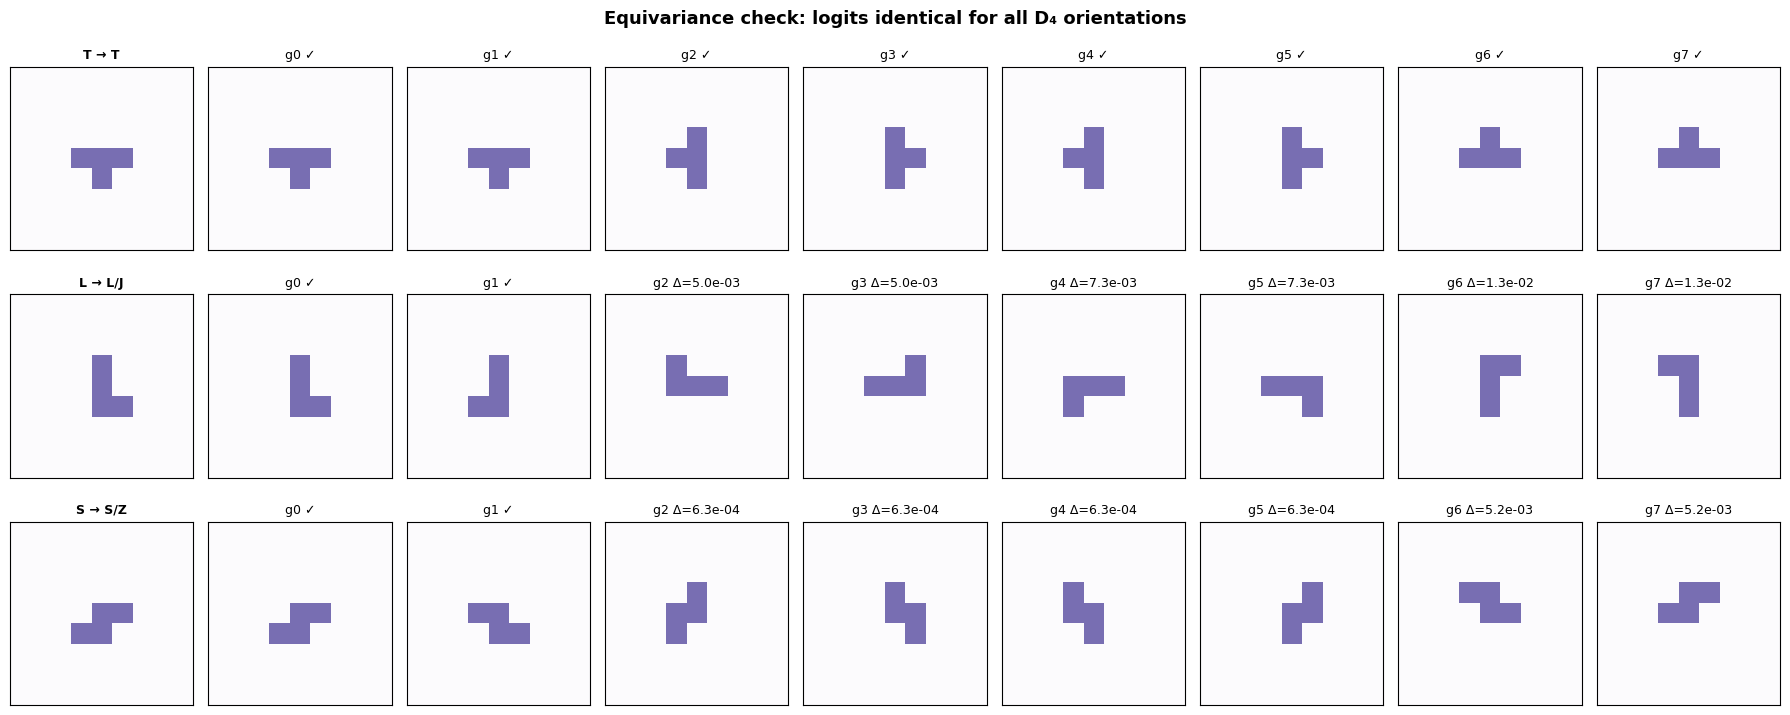

In [12]:
def verify_equivariance(model, test_pieces=['T', 'L', 'S']):
    model.eval()
    perm_rep_full = image2D_permutation_representation(D4_torch, [GRID_SIZE, GRID_SIZE])

    fig, axes = plt.subplots(len(test_pieces), len(D4) + 1,
                             figsize=(2 * (len(D4) + 1), 2.5 * len(test_pieces)))
    for row, name in enumerate(test_pieces):
        img = place_piece(PIECES[name], GRID_SIZE, (CENTER, CENTER))
        img_t = torch.tensor(img, dtype=torch.float32).reshape(1, 1, GRID_SIZE, GRID_SIZE)
        with torch.no_grad():
            logits_orig = model(img_t)
            pred = D4_CLASS_NAMES[logits_orig.argmax(1).item()]

        ax = axes[row, 0]
        ax.imshow(img, cmap='Purples', vmin=0, vmax=1.5, interpolation='nearest')
        ax.set_title(f'{name} → {pred}', fontsize=9, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

        for g_idx in range(len(D4)):
            rot_flat = perm_rep_full[g_idx] @ torch.tensor(img.flatten(), dtype=torch.float32)
            rot_img = rot_flat.reshape(GRID_SIZE, GRID_SIZE)
            with torch.no_grad():
                logits_rot = model(rot_img.reshape(1, 1, GRID_SIZE, GRID_SIZE))
                max_diff = (logits_rot - logits_orig).abs().max().item()
            ax = axes[row, g_idx + 1]
            ax.imshow(rot_img.numpy(), cmap='Purples', vmin=0, vmax=1.5, interpolation='nearest')
            mark = '✓' if max_diff < 1e-4 else f'Δ={max_diff:.1e}'
            ax.set_title(f'g{g_idx} {mark}', fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle('Equivariance check: logits identical for all D₄ orientations',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


verify_equivariance(model)

---
## 10. Experimenting with Irrep Content

Try changing the hidden irrep content and see how it affects training. The cell below rebuilds with a different choice.

In [13]:
# Try: minimal content — one copy of each (6-dim, smaller than regular rep)
hidden_content_v2 = [(A1, 1), (A2, 1), (B1, 1), (B2, 1), (E, 1)]  # A1+A2+B1+B2+E = 6 dim
hidden_slices_v2 = content_norm_slices(hidden_content_v2, D4_irreps)

lift_elems_v2, _, n_lift_v2, _, _ = steerable_kernel_basis(
    D4_irreps, sp_basis, scalar_content, hidden_content_v2)
conv_elems_v2, _, n_conv_v2, _, _ = steerable_kernel_basis(
    D4_irreps, sp_basis, hidden_content_v2, hidden_content_v2)

print(f"Minimal content: {sum(d for _,_,d in hidden_slices_v2)}-dim hidden features")
print(f"  Conv1: {n_lift_v2} paths, Conv2: {n_conv_v2} paths")


class SteerableTetrisCNN_v2(nn.Module):
    def __init__(self, c=16, num_classes=5):
        super().__init__()
        self.conv1 = SteerableConv2d(1, c, lift_elems_v2, kernel_size=(3, 3))
        self.conv2 = SteerableConv2d(c, c, conv_elems_v2, kernel_size=(3, 3))
        self.fc = nn.Linear(c, num_classes)
        self.hidden_slices = hidden_slices_v2
        n_blocks = len(hidden_slices_v2)
        self.act_bias1 = nn.Parameter(torch.zeros(n_blocks))
        self.act_bias2 = nn.Parameter(torch.zeros(n_blocks))

    def forward(self, x):
        x = x.unsqueeze(2)
        x = self.conv1(x)
        x = norm_activation(x, self.hidden_slices, self.act_bias1)
        x = self.conv2(x)
        x = norm_activation(x, self.hidden_slices, self.act_bias2)
        x = x.mean(dim=(-2, -1))
        x = x[:, :, 0]
        return self.fc(x)


torch.manual_seed(0)
model_v2 = SteerableTetrisCNN_v2()
n_params_v2 = sum(p.numel() for p in model_v2.parameters())
print(f"\nParameters: {n_params_v2:,} (vs {n_params:,} with 8-dim hidden)")
history_v2 = train_model(model_v2, train_imgs, train_labels, test_imgs, test_labels)

Minimal content: 6-dim hidden features
  Conv1: 7 paths, Conv2: 41 paths

Parameters: 10,703 (vs 4,737 with 8-dim hidden)
Epoch  25: loss=1.3337  train_acc=0.400  test_acc=0.429
Epoch  50: loss=0.6732  train_acc=1.000  test_acc=1.000
Epoch  75: loss=0.2415  train_acc=1.000  test_acc=1.000
Epoch 100: loss=0.0636  train_acc=1.000  test_acc=1.000
Epoch 125: loss=0.0215  train_acc=1.000  test_acc=1.000
Epoch 150: loss=0.0125  train_acc=1.000  test_acc=1.000
Epoch 175: loss=0.0075  train_acc=1.000  test_acc=1.000
Epoch 200: loss=0.0053  train_acc=1.000  test_acc=1.000


---
## Summary

| | Steerable CNN | Regular-rep group CNN |
|---|---|---|
| **Features** | Irrep components ($A_1, A_2, B_1, B_2, E$) | Group element index ($g_0, g_1, \ldots, g_7$) |
| **Filter** | Scalar weights $\times$ fixed CG basis | Free weights on group $\times$ spatial grid |
| **Channels** | Fully connected; same basis for all channel pairs | Fully connected; same filter bank for all channels |
| **Precomputation** | CG $\times$ spatial basis (for fixed grids) | Filter bank (rotate filter by each $g$) |
| **Nonlinearity** | Norm-based (bias on norm, not on features) | Pointwise ReLU (works because reg rep permutes) |
| **Numerical precision** | Float-valued basis $\to$ ~1e-4 equivariance error in float32 | $D^{\text{reg}}$ is a permutation matrix (0s and 1s) $\to$ less float accumulation |
| **Irrep content** | Tunable hyperparameter | Fixed at regular rep |
| **Scales to continuous groups** | Yes (finite irrep truncation) | No (regular rep is infinite-dimensional) |

The steerable approach becomes essential for **continuous groups** like $\text{SO}(3)$, where the regular representation is infinite-dimensional but we can work with finitely many irreps (spherical harmonics). Everything we built here — CG-parameterized filters, norm activations, irrep content as a hyperparameter — carries over directly.